In [1]:
import os
import pandas as pd
import numpy as np
import json
from collections import defaultdict
import matplotlib.pyplot as plt
from utils.evaluation import mean_confidence_interval


In [2]:
def plot_subplots(metadata, metrics, vertical=True):
    x_ = list(metadata.keys())
    if vertical:
        fig, ax = plt.subplots(1, len(metrics),figsize = (8.27,2.5),dpi=150, sharex=True)
    else:
        fig, ax = plt.subplots(len(metrics),1,figsize = (4,6),dpi=150, sharex=True)
    for i,metric in enumerate(metrics):
        y_ = [mtd['mean'][metric] for episode, mtd in metadata.items()]
        err_ = np.array([mtd['std'][metric] for episode, mtd in metadata.items()])
        # ax[i].errorbar(x_, y_, yerr = err_)
        ax[i].fill_between(x_, y_ - err_, y_ + err_, alpha=0.3)
        ax[i].plot(x_, y_, label=metric)
        ax[i].set_ylabel(metric)
        ax[i].set_xlabel('episode')
        ax[i].grid()
    plt.tight_layout()
    

In [ ]:
# UPDATE THIS WITH THE CORRECT FOLDER TRAINING PROCESS
TIMESTAMP = '20250727_225151'
FOLDER_X = f'./models/{TIMESTAMP}' 
with open(os.path.join(FOLDER_X,'params.json'), 'r') as fin:
    args = json.load(fin)

args


{'num_pursuers': 1,
 'map_width': 1,
 'map_height': 1,
 'pursuer_speed': 0.0077,
 'evader_speed': 0.0077,
 'pursuer_max_acceleration': 2.827433388230814,
 'evader_max_acceleration': 2.827433388230814,
 'r_min': 0.025,
 'r_shoot': 0.1,
 'dt': 1,
 'beta': 1000,
 'communication_penalty': 1.0,
 'time_penalty': 0.5,
 'hit_boundary_penalty': 10,
 'lat_acceleration_penalty': 0.5,
 'shooting_penalty': 100,
 'distance_penalty': 100,
 'max_steps': 1000,
 'communication': True,
 'smart_e': True,
 'probabilistic': True,
 'lambd': 2,
 'generalization': True,
 'hidden_dim': 256,
 'discount': 0.99,
 'tau': 0.005,
 'policy_noise': 0.2,
 'noise_clip': 0.5,
 'policy_delay': 5,
 'expl_noise': 0.1,
 'replay_buffer_size': 1000000,
 'gae_lambda': 0.95,
 'policy_clip': 0.2,
 'lr': 0.0003,
 'history_len': 1,
 'multiheadPPO': False,
 'PDQN': False,
 'start_time_steps': 15000,
 'max_timesteps': 6000000,
 'batch_size': 32,
 'save_model': True,
 'eval_freq': 250,
 'eval_episodes': 50,
 'seed': 3,
 'load_seed': 1,

In [4]:
episode_folders = os.listdir(FOLDER_X)
episode_folders = [item for item in episode_folders if not item.endswith('json')]
episode_folders = [item for item in episode_folders if not item.endswith('.csv')]

metadata = {}
for episode_folder in episode_folders:
    file_path = os.path.join(FOLDER_X,episode_folder, 'df_stats.csv')

    df_evaluation_step = pd.read_csv(file_path)
    mean_stats = df_evaluation_step.drop('episode',axis=1).mean().to_dict()
    std_stats = df_evaluation_step.drop('episode',axis=1).std().to_dict()
    
    ci = np.array([mean_confidence_interval(df_evaluation_step[column].fillna(0).tolist()) for column in df_evaluation_step.drop('episode',axis=1).columns.tolist()])
    ci[np.isnan(ci)] = 0
    metrics = df_evaluation_step.drop('episode',axis=1).columns.tolist()
    std_stats = dict(zip(metrics, ci.tolist()))
    

    metadata[int(episode_folder)] = {}
    metadata[int(episode_folder)]['mean'] = mean_stats
    metadata[int(episode_folder)]['std'] = std_stats

# Sort keys, plot_subplots assumes it
metadata = {k: metadata[k] for k in sorted(metadata)}


In [5]:
len(metadata)*100

6100

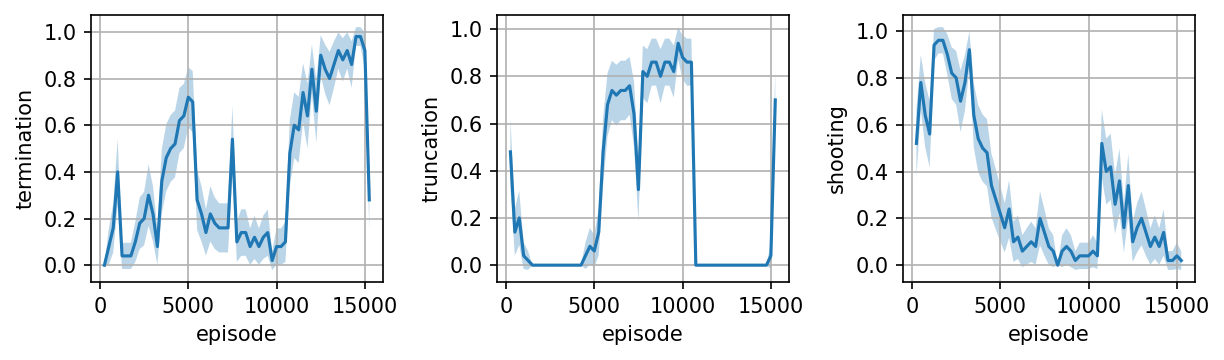

In [7]:
plot_subplots(metadata, ['termination','truncation','shooting'], vertical=True)


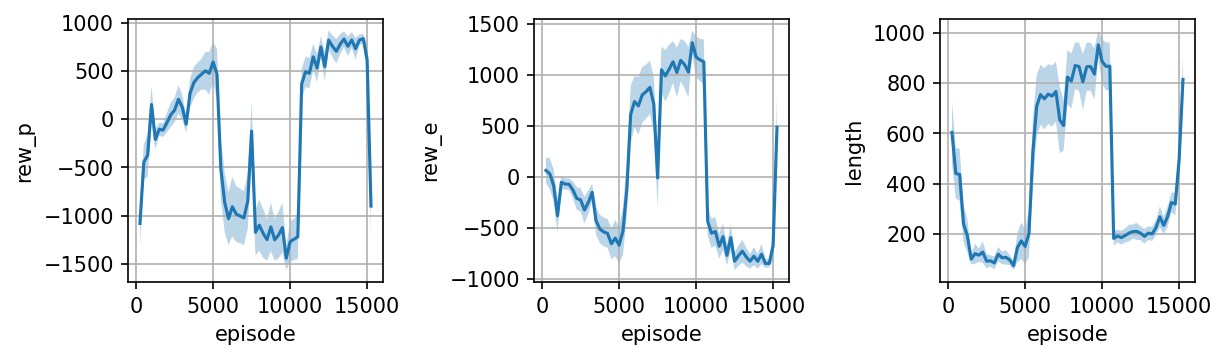

In [8]:
plot_subplots(metadata, metrics=['rew_p','rew_e','length'], vertical=True)


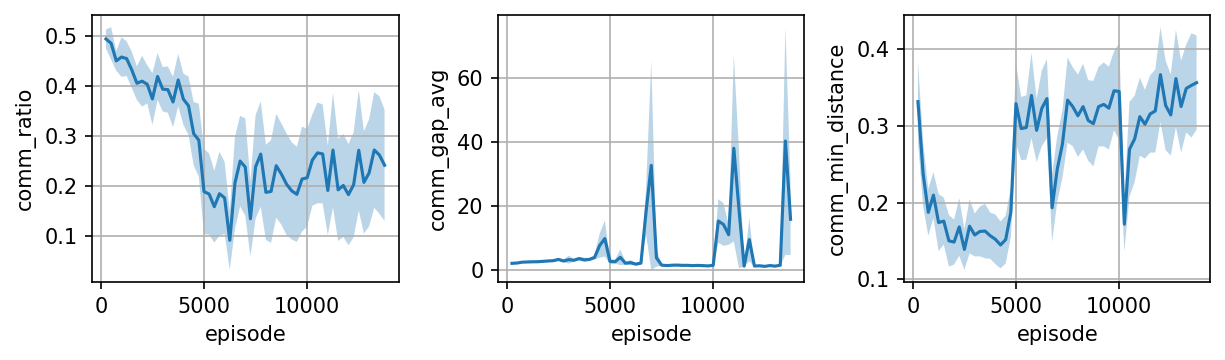

In [32]:
plot_subplots(metadata,metrics=['comm_ratio','comm_gap_avg','comm_min_distance'], vertical=True)

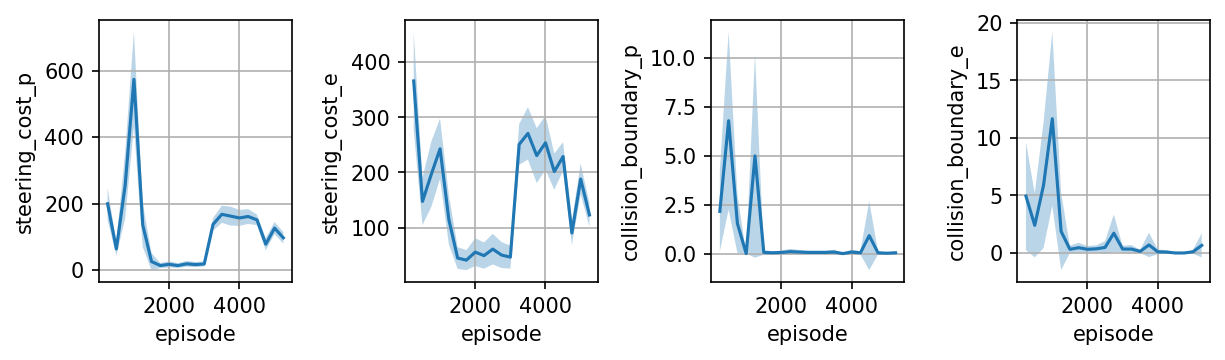

In [20]:
plot_subplots(metadata,metrics=['steering_cost_p','steering_cost_e','collision_boundary_p','collision_boundary_e'])
